# DSA 107 — Lab 2: Summarising one variable, then two

**Week 2 · w/c 5 October 2026** · paired with DSA 101 lecture week 2

**Name:** Andrei Tiniakov   **Student ID:** 26022121102

---

### What you will produce

A runnable Colab notebook, pushed to your `dsa107-labs` repository. In it you summarise one categorical variable, count two categorical variables together, turn those counts into rates, summarise one quantitative variable, and draw three labelled figures.

### Before you start

Run the setup cell below. If any import fails, run
`!pip install pandas matplotlib seaborn` in a new cell and try again.

### How to use this notebook

Every code cell has a **Goal** written just above it. Read the goal, then write the code. You do not need to open the handout while you work — everything you have to do is in this notebook.

The **Command reference** below holds the commands you need for this lab, and a few more besides. Read it once now, and come back to it whenever you are stuck.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")
print("pandas", pd.__version__)

pandas 3.0.6


## Command reference

`df` means a whole table (a DataFrame). `s` means a single column (a Series).
Not every command here is needed for this lab — choosing the right one is part of the work.

**Looking at the table**

| Command | What it does |
| --- | --- |
| `pd.read_csv(url)` | reads a CSV file, from a web address or from your computer |
| `df.head(n)` | returns the first `n` rows (5 if you do not say) |
| `df.tail(n)` | returns the last `n` rows |
| `df.shape` | gives (number of rows, number of columns) |
| `len(df)` | gives the number of rows |
| `df.info()` | prints the column names, their types and their non-missing counts |
| `df.describe()` | prints count, mean, std, min, quartiles and max for the numeric columns |

**Missing values, and sorting**

| Command | What it does |
| --- | --- |
| `df.isna().sum()` | gives the number of missing values in each column |
| `s.sort_values()` | sorts from smallest to largest |
| `s.sort_values(ascending=False)` | sorts from largest to smallest |

**One categorical column**

| Command | What it does |
| --- | --- |
| `df["col"]` | picks out one column |
| `s.value_counts()` | counts how many times each value appears |
| `s.value_counts(normalize=True)` | the same, as proportions that add up to 1 |
| `s.sort_index()` | sorts by category name instead of by count |
| `s.nunique()` | counts how many different values there are |

**Two categorical columns together**

| Command | What it does |
| --- | --- |
| `pd.crosstab(a, b)` | counts every combination; `a` runs down the side, `b` across the top |
| `pd.crosstab(a, b, normalize="index")` | divides every cell by its own **row** total |
| `pd.crosstab(a, b, normalize="columns")` | divides every cell by its own **column** total |
| `table.sum(axis="columns")` | adds up each row, giving one total per row |
| `table.sum(axis="index")` | adds up each column, giving one total per column |
| `table.loc[3, 0]` | picks out one cell, by its row label and column label (numbers, no quotes) |

**One quantitative column**

| Command | What it does |
| --- | --- |
| `s.mean()` | the mean: add every value, divide by how many |
| `s.median()` | the median: sort the values and take the middle one |
| `s.std()` | the standard deviation: roughly, the typical distance from the mean |
| `s.min()` / `s.max()` | the smallest / the largest value |
| `round(x, 2)` | rounds one number to 2 decimal places |
| `table.round(3)` | rounds every cell of a table |

**Drawing and labelling**

The `.plot` commands hand you back an *axes* object. Catch it in a variable and you can label it.

| Command | What it does |
| --- | --- |
| `ax = s.plot.bar()` | draws a bar chart, one bar per row, and keeps the axes in `ax` |
| `ax = table.plot.bar()` | draws grouped bars, one group per row |
| `ax = s.plot.hist(bins=20)` | draws a histogram with 20 bins |
| `ax.set_xlabel("...")` | names the horizontal axis |
| `ax.set_ylabel("...")` | names the vertical axis |
| `ax.set_title("...")` | puts a title on the figure |
| `ax.legend(title="...")` | names the legend |
| `plt.show()` | shows the finished figure |

A figure in this course is not finished until it has both axis labels and a title.

## 1. Load the data and look at it

`pd.read_csv` accepts a URL just as happily as a filename.

This is a Titanic passenger list, but **it is not the same file used in the lecture**. Your numbers will not match your lecture notes, and they are not supposed to. The method is what carries over, not the answers.

> **Goal 1a.** Load the CSV into a DataFrame called `titanic`, then show its first five rows.

In [3]:
titanic = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv")

# TODO: show the first five rows
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


> **Goal 1b.** Print the shape of the table, then print the column names, their types and their non-missing counts.

In [4]:
# TODO: print the shape, then call .info()
print("shape:", titanic.shape)
titanic.info()

shape: (891, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


> **Goal 1c.** Count the missing values in each column, and show the worst column first.

In [13]:
# TODO: count the missing values per column, sorted from most to fewest
titanic.isna().sum().sort_values(ascending=False)

,0
deck,688
age,177
embarked,2
embark_town,2
sex,0
pclass,0
survived,0
fare,0
parch,0
sibsp,0


In [17]:
titanic["deck"].isna().sum() / len(titanic)

np.float64(0.7721661054994389)

**Q1.** How many rows and how many columns are there, and what does one row represent?
Which column has the most missing values, roughly what fraction of the rows is that, and would you use that column in an analysis?

*Write your answer here.*

Answer:
There are 891 rows and 15 columns
Each row represents a single passnager on titanic
Deck column has the most missing values (688 rows), which is approximetly is 77% of dataset rows. The column can be used but we need to be careful since we don't know the reason why this column is absent for most of the dataset

## 2. One categorical variable

A **categorical** variable puts each row into a group: `sex`, `embarked`, `pclass`.
A **quantitative** variable measures an amount: `age`, `fare`.

Be careful: `pclass` is stored as the numbers 1, 2 and 3, but it is still categorical. The number 2 is a label, not an amount — second class is not "twice" first class. How a variable is *stored* and what kind of variable it *is* are two different questions.

For a categorical variable the summary is a count of every category. That table of counts has a name: the **distribution** of the variable.

> **Goal 2a.** Count how many passengers were in each class. Sort the result by class number, not by count, and store it in a variable called `counts_class` so you can draw it later.

In [4]:
# TODO: counts of each passenger class, in class order, stored as counts_class
counts_class = {}
for pclass in titanic["pclass"]:
  if pclass not in counts_class:
    counts_class[pclass] = 1
  else:
    counts_class[pclass] += 1

counts_class = dict(sorted(counts_class.items()))
print(counts_class)

{1: 216, 2: 184, 3: 491}


> **Goal 2b.** Show the same summary as proportions instead of counts, and check that they add up to 1.

In [5]:
# TODO: the same table as proportions, plus a check that they sum to 1
totalSize = len(titanic)
print(totalSize)

total = 0

for pclassCount in counts_class.values():
  value = pclassCount / totalSize
  print(value)
  total += value

print(total)

891
0.24242424242424243
0.20650953984287318
0.5510662177328844
1.0


> **Goal 2c.** Draw a bar chart of the class counts. Give it an x label, a y label and a title.

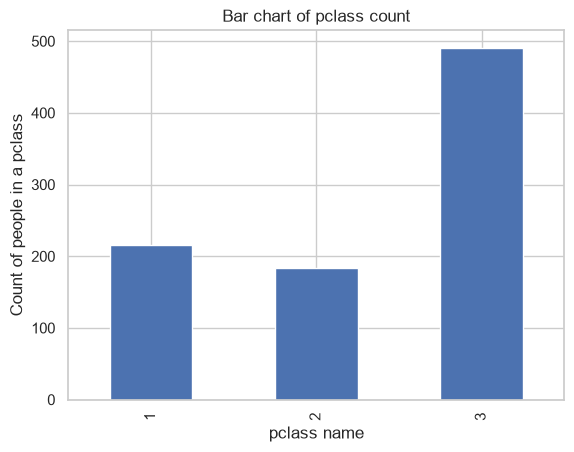

In [6]:
# TODO: labelled bar chart of the class counts
s = pd.Series(counts_class)

ax = s.plot.bar()


ax.set_title("Bar chart of pclass count")
ax.set_xlabel("pclass name")
ax.set_ylabel("Count of people in a pclass")

plt.show()



In [7]:

print(counts_class[1]/totalSize)
print(counts_class[2]/totalSize)
print(counts_class[3]/totalSize)


0.24242424242424243
0.20650953984287318
0.5510662177328844


**Q2.** What fraction of the passengers travelled in third class?
If you picked one passenger from this dataset at random, what is the probability that they were in first class?
Write one sentence explaining why a proportion and a probability are the same number here.

*Write your answer here.*
Answer:
About 55% of passangers were in the 3rd class. If i picked one passanger at random the chance of them being in the first class would be about 24%. In current contextn proportion and probability is the same number because we have the same total number (the size of the dataset): to calculate proprtion we take the count of passangers in a given pclass and devide it by the total count of passagners.

## 3. Two variables, and the denominator question

One variable on its own cannot answer "did class affect survival". You need the pair.

`pd.crosstab` counts every combination of two variables. The first argument runs down the side of the table, the second runs across the top.

Then comes the hard idea of the week. **The same six numbers become different tables depending on what you divide by, and the denominator is the question you are asking.**

| Table | Divide every cell by | The question it answers |
| --- | --- | --- |
| Joint | the grand total | P(third class **and** died) |
| Marginal | nothing — just add up | P(third class) |
| Conditional | its own row total | P(died **given** third class) |

Only the conditional table compares groups of different sizes fairly, because every row adds up to 1 whatever the size of the group.

> **Goal 3a.** Make a crosstab with `pclass` down the side and `survived` across the top. Store it in a variable called `counts` and print it.

In [8]:
# TODO: build the crosstab and print it
counts = pd.crosstab(titanic["pclass"], titanic["survived"])
counts

survived,0,1
pclass,,
1,80,136
2,97,87
3,372,119


> **Goal 3b.** Add up each row of `counts` to get the number of passengers in each class — the marginal counts. Check that they add up to the number of rows in the dataset.

In [9]:
# TODO: row totals, and a check against len(titanic)
rows_total = counts.sum(axis = "columns")
print(rows_total)
print(rows_total.sum())
print(totalSize)

pclass
1    216
2    184
3    491
dtype: int64
891
891


> **Goal 3c.** Build the conditional distribution: every cell divided by its own row total. Store it as `rates`, print it rounded to 3 decimal places, and check that every row adds up to 1.

In [10]:
# TODO: the conditional distribution, rounded to 3 places, plus a row check
rates = pd.crosstab(
    titanic["pclass"],
    titanic["survived"],
    normalize="index"
)
print(rates.round(3))

print(rates.sum(axis="columns"))

survived      0      1
pclass                
1         0.370  0.630
2         0.527  0.473
3         0.758  0.242
pclass
1    1.0
2    1.0
3    1.0
dtype: float64


> **Goal 3d.** Draw a bar chart of `rates`, with one group of bars per class. Label both axes, the legend and the title.

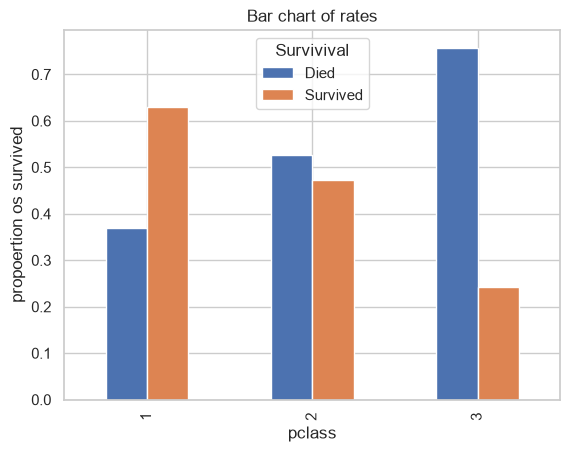

In [11]:
# TODO: labelled bar chart of the conditional rates
ax = rates.plot.bar()

ax.set_title("Bar chart of rates")
ax.set_xlabel("pclass")
ax.set_ylabel("propoertion os survived")

ax.legend(["Died", "Survived"],title="Survivival")

plt.show()

**Q3.** Which single cell of `counts` holds the largest number, and what does that cell mean? Does that number on its own show that this was the most dangerous class to travel in?

Now look at `rates`. Given that a passenger travelled in third class, what fraction survived, and how does that compare with first class?

In one sentence: which of the two tables answers "did class affect survival", and why?

*Write your answer here.*

1) It's 3rd pclass deaths (being at over 70% of deaths in the pclass). However there could be different factors to those deaths, to be sure we need to investigate the whole data set since there could be other factors (for exmaple - it's possible that 3rd class would have more elderly people). But if we looked ony at the class we could say that being in the 3rd class is more deadly.
2) In the 3rd class less then 25% survived, which makes it the worst survival rate out of all 3 classes. In particular compared to the first class it makes 3rd class about 2.6 times worse.
3) This rates bar shows that 3rd class was deadlisest from all 3, then 2nd and then 1st being the safest, and we can see it clearly in the bar chart by looking at the surival rate of each class.

## 4. One quantitative variable

`value_counts` is a poor tool for `age`. There are 88 different ages in this dataset, so the table would be 88 rows long, and each row would carry very little information on its own. You cannot see a shape in a table like that.

So instead we cut the range of ages into **bins**, and count how many values fall into each bin. That is a histogram.

The number of bins is a choice you make. Too few bins hide real structure. Too many bins show noise as if it were structure. There is no correct number — only a number you can defend.

> **Goal 4a.** Draw a histogram of `age` with 10 bins. Label both axes and give it a title that says how many bins you used. Then try one other bin count and keep whichever you prefer.

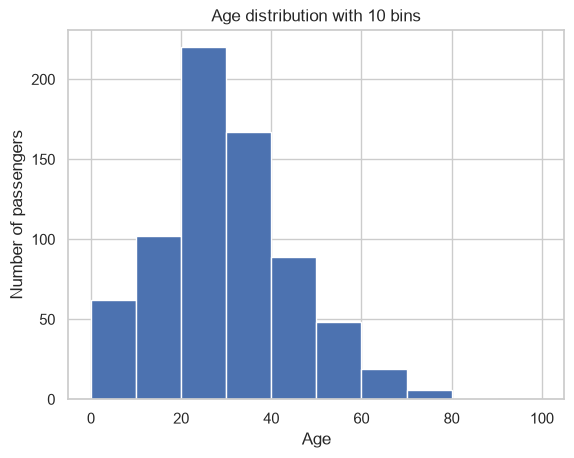

In [12]:
# TODO: labelled histogram of age

bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

ax = titanic["age"].plot.hist(bins=bins)

ax.set_xlabel("Age")
ax.set_ylabel("Number of passengers")
ax.set_title("Age distribution with 10 bins")

plt.show()

> **Goal 4b.** Print the mean, the median and the standard deviation of `age`. Then print the mean, the median and the largest value of `fare`. Round everything to 2 decimal places.

In [13]:
# TODO: centre and spread for age, then centre and largest value for fare
age = titanic["age"]
fare = titanic["fare"]

print("age mean:", round(age.mean(), 2))
print("age median:", round(age.median(), 2))
print("age standard deviation:", round(age.std(), 2))

print("fare mean:", round(fare.mean(), 2))
print("fare median:", round(fare.median(), 2))
print("fare max:", round(fare.max(), 2))

age mean: 29.7
age median: 28.0
age standard deviation: 14.53
fare mean: 32.2
fare median: 14.45
fare max: 512.33


**Q4.** Looking at your age histogram, roughly where is the biggest group of passengers?

For `fare`, the mean and the median are far apart. Which one is the honest summary of a typical fare, and what does the size of the gap tell you about the shape of the data?

*Write your answer here.*
1) 20-30 yeats old
2) Median is better for telling a a tipical price which is about 14 but mean is pulled up beacause of a small number of expensive tickers. The fact that there is such difference in those values means that ticket pirces are highly scattered (most tickets are cheap but there are few very expensive)

## 5. Push to GitHub

1. You created a repository named `dsa107-labs` in Lab 1. Use the same one.
2. In Colab: **File → Save a copy in GitHub**, and choose that repository.
3. Paste the resulting link in the line below.

**Repository link:** https://github.com/AndrewTinyakov/dsa107-labs

---

## Submission checklist

- [ ] Every cell runs top to bottom without error (Runtime → Restart and run all)
- [ ] All three figures have an x label, a y label and a title
- [ ] All four written answers are filled in — a figure with no reading of it scores zero on interpretation
- [ ] Notebook saved as `Lab02_Firstname_Lastname.ipynb`
- [ ] Report exported as `Lab02_Firstname_Lastname.pdf`
- [ ] If you used an AI assistant, the log is attached as described in the course AI policy

Submit both files through MS Teams.

AI usage:

ax = s.plot.bar()
in this context what is s
i need to draw a bar chart

Here, s is just a variable name. In this example, it represents a Pandas Series.
Think of it like this:
import pandas as pds = pd.Series({    "Apple": 10,    "Banana": 7,    "Orange": 12})


Then:
ax = s.plot.bar()plt.show()


draws one bar for every value in the Series:
Apple   ██████████      10
Banana  ███████          7
Orange  ████████████    12

So this:
s.plot.bar()


does not mean that s is some special Matplotlib command. s is simply whatever Series you created earlier.
If you need to draw a bar chart
Suppose your DataFrame is:
df


and it looks like:
         species    count
0        Adelie      152
1     Chinstrap       68
2        Gentoo      124

You could do:
s = df.set_index("species")["count"]ax = s.plot.bar()ax.set_xlabel("Species")ax.set_ylabel("Count")ax.set_title("Number of penguins by species")plt.show()


The important part is:
s = df.set_index("species")["count"]


Now s is:
species
Adelie       152
Chinstrap     68
Gentoo       124

and:
s.plot.bar()


uses the index as the x-axis and the values as the bar heights.
If you show me the DataFrame you have and what the exercise asks you to plot, I can show you exactly what s should be in your case.
---
what if i have a map?

If by "map" you mean a Python dictionary like this:
counts = {    "Adelie": 152,    "Chinstrap": 68,    "Gentoo": 124}


then you can turn it into a Pandas Series and use the exact same .plot.bar():
s = pd.Series(counts)ax = s.plot.bar()ax.set_xlabel("Species")ax.set_ylabel("Count")ax.set_title("Penguins by species")plt.show()


A dictionary:
{    "Adelie": 152,    "Chinstrap": 68,    "Gentoo": 124}


becomes this Series:
Adelie       152
Chinstrap     68
Gentoo       124
dtype: int64

So the keys become the x-axis labels, and the values become the bar heights.
You can also skip the s variable:
ax = pd.Series(counts).plot.bar()plt.show()


If by "map" you mean the Python map() function rather than a dictionary, that's a different thing.

---
Goal 3c. Build the conditional distribution: every cell divided by its own row total. Store it as rates, print it rounded to 3 decimal places, and check that every row adds up to 1.

now explain it to me with simpler words
and remind me how to print something rounded


The idea is simple.
Right now counts has raw numbers, something like:
survived    0    1pclass1          80  1362          97   873         372  119


For each row, you want to ask:
"Out of everyone in this class, what fraction died and what fraction survived?"

So instead of keeping 80 and 136, you divide both by that row's total:
80 / (80 + 136)
136 / (80 + 136)

Then that row will add up to 1.
Since Pandas can do this directly, you can use:
rates = pd.crosstab(    titanic["pclass"],    titanic["survived"],    normalize="index")


normalize="index" means:
divide every value by the total of its own row

How to print rounded values
For Pandas tables or Series:
print(rates.round(3))


3 means 3 decimal places.
For example:
0.370370...

becomes:
0.370

And to check that every row adds up to 1:
print(rates.sum(axis="columns"))


You should get something like:
1.0
1.0
1.0

So the three things to remember here are:
normalize="index"        # turn each row into proportions.round(3)                # round to 3 decimal places.sum(axis="columns")     # add across each row
---

how to label the legend


Use the title= argument inside legend().
For example:
ax.legend(title="Survived")


That will keep the legend entries as 0 and 1, but add a title above them:
Survived
0
1

In your case, this is probably what the exercise wants:
ax.legend(title="Survived")


If you want to rename the actual entries too, you can do:
ax.legend(["Died", "Survived"], title="Survival")


So the difference is:
title="..."


labels the whole legend, while:
["Died", "Survived"]


changes the names of the individual legend items.

---

now remind me how to create a histogram
i remember that we need to pass a list of bins which would do the thing with separation into groups
let's make it as 10 20 30 etc

i think it was somehting like ax = titanic["age"].plot.hist()

Yes. For a histogram, bins can be a list of the boundaries between groups.
If you want age groups like:
0–10
10–20
20–30
...
90–100

you write:
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]


Notice something important: 11 boundaries create 10 bins.
Then plot only the age column:
ax = titanic["age"].plot.hist(bins=bins)


And label it the same way you did before:
ax.set_xlabel("Age")ax.set_ylabel("Number of passengers")ax.set_title("Age distribution with 10 bins")plt.show()


So altogether:
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]ax = titanic["age"].plot.hist(bins=bins)ax.set_xlabel("Age")ax.set_ylabel("Number of passengers")ax.set_title("Age distribution with 10 bins")plt.show()


The key thing to understand is that:
bins=[0, 10, 20, 30]


means:
0 ≤ age < 10
10 ≤ age < 20
20 ≤ age ≤ 30

So the numbers in bins are the walls separating the groups, not the groups themselves.
Also, if you don't care exactly where the boundaries are and just want Pandas to split the ages into 10 groups automatically, you can simply do:
titanic["age"].plot.hist(bins=10)


But your manual 0, 10, 20, ... version is easier to interpret.

---

Q4. Looking at your age histogram, roughly where is the biggest group of passengers?

For fare, the mean and the median are far apart. Which one is the honest summary of a typical fare, and what does the size of the gap tell you about the shape of the data?

remind me what fare means
i know that since it's spread like this it means that there are huge spikes in the data where most rows are the same and then some of them is drastically different



fare means the ticket price paid by the passenger.
And yes, your interpretation is basically right.
Here you have:
fare mean:   32.20
fare median: 14.45
fare max:   512.33

The median says the "middle" passenger paid about 14.45.
But the mean is much higher, 32.20. That happens because some passengers paid very large fares, like values near 512, and those expensive tickets pull the mean upward.
So the distribution is not symmetric. It is strongly right-skewed:
many passengers
pay relatively low fares

██████████████████████
████████████████
████████
████
██
█
█                         █
low                     very high fare

One small correction to what you said: it does not necessarily mean "most rows are the same." It means most values are relatively low, while a smaller number of very high values create a long tail.

---